In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score

DukaanBrain — Retail Intelligence for Small Businesses

DukaanBrain is an experimental retail-intelligence system designed to turn transaction data into understandable business insights for small and medium-sized retailers.

In this notebook, I focus on three questions:

1. What is happening in the store?
I perform exploratory data analysis on transactions, products, categories, customers and sales trends.

2. What types of customers does the store have?
I use RFM feature engineering and K-Means clustering to identify customer behaviour segments.

3. Can historical information provide a basic signal about future sales?
I build a simple Linear Regression baseline and evaluate its limitations before considering more advanced forecasting models.

The objective is not just to obtain an ML score, but to connect the analysis to decisions a retailer could actually understand and use.

Notebook Roadmap


DukaanBrain - Retail Intelligence System

1. Data Loading
2. Dataset Understanding
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
      - Sales distribution
      - Top products
      - Top categories
      - Monthly sales
      - Customer analysis

6. Customer Segmentation
      RFM
       ↓
   StandardScaler
       ↓
     KMeans
       ↓
   Customer Groups

7. Sales Prediction
      Daily Sales
          ↓
   Feature Creation
          ↓
   Linear Regression
          ↓
      Evaluation

In [151]:
df = pd.read_csv("../data/scanner_data.csv")

In [152]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,02/01/2016,2547,1,X52,0EM7L,1.0,3.13
1,02/01/2016,822,2,2ML,68BRQ,1.0,5.46
2,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35
3,02/01/2016,3719,4,0H2,549KK,1.0,5.59
4,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88


## 1. Loading and Understanding the Dataset

I first load the transaction data and inspect its structure before making any transformations. I check the dimensions, column types, missing values, duplicates and number of unique values.

This step helps identify basic data-quality problems before performing EDA or machine learning.

In [153]:
df.describe()

,Customer_ID,Transaction_ID,Quantity,Sales_Amount
count,131706.000000,131706.000000,131706.000000,131706.000000
mean,12386.450367,32389.604187,1.485311,11.981524
std,6086.447552,18709.901238,3.872667,19.359699
min,1.000000,1.000000,0.010000,0.020000
25%,7349.000000,16134.000000,1.000000,4.230000
50%,13496.000000,32620.000000,1.000000,6.920000
75%,17306.000000,48548.000000,1.000000,12.330000
max,22625.000000,64682.000000,400.000000,707.730000


In [154]:
df.shape

(131706, 7)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            131706 non-null  object 
 1   Customer_ID     131706 non-null  int64  
 2   Transaction_ID  131706 non-null  int64  
 3   SKU_Category    131706 non-null  object 
 4   SKU             131706 non-null  object 
 5   Quantity        131706 non-null  float64
 6   Sales_Amount    131706 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 7.0+ MB


In [156]:
df.isnull().sum()

Date              0
Customer_ID       0
Transaction_ID    0
SKU_Category      0
SKU               0
Quantity          0
Sales_Amount      0
dtype: int64

In [157]:
df.duplicated().sum()

np.int64(0)

In [158]:
df.nunique()

Date                363
Customer_ID       22625
Transaction_ID    64682
SKU_Category        187
SKU                5242
Quantity             83
Sales_Amount       3233
dtype: int64

In [159]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df["Date"].head()

0   2016-01-02
1   2016-01-02
2   2016-01-02
3   2016-01-02
4   2016-01-02
Name: Date, dtype: datetime64[ns]

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            131706 non-null  datetime64[ns]
 1   Customer_ID     131706 non-null  int64         
 2   Transaction_ID  131706 non-null  int64         
 3   SKU_Category    131706 non-null  object        
 4   SKU             131706 non-null  object        
 5   Quantity        131706 non-null  float64       
 6   Sales_Amount    131706 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 7.0+ MB


In [161]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["day_of_week"] = df["Date"].dt.day_name()

In [162]:
df["UnitPrice"] = df["Sales_Amount"] / df["Quantity"]

I converted the date column into datetime features and derived unit price from sales amount and quantity.

## 2. Data Cleaning and Feature Engineering

The `Date` column was originally stored as text in `DD/MM/YYYY` format, so I convert it into a proper datetime object.

From the date I derive calendar features such as year, month, day and day of week. These features are useful for studying sales patterns over time.

I also derive unit price from sales amount and quantity.

In [163]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            131706 non-null  datetime64[ns]
 1   Customer_ID     131706 non-null  int64         
 2   Transaction_ID  131706 non-null  int64         
 3   SKU_Category    131706 non-null  object        
 4   SKU             131706 non-null  object        
 5   Quantity        131706 non-null  float64       
 6   Sales_Amount    131706 non-null  float64       
 7   year            131706 non-null  int32         
 8   month           131706 non-null  int32         
 9   day             131706 non-null  int32         
 10  day_of_week     131706 non-null  object        
 11  UnitPrice       131706 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int32(3), int64(2), object(3)
memory usage: 10.6+ MB


,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,year,month,day,day_of_week,UnitPrice
0,2016-01-02,2547,1,X52,0EM7L,1.0,3.13,2016,1,2,Saturday,3.13
1,2016-01-02,822,2,2ML,68BRQ,1.0,5.46,2016,1,2,Saturday,5.46
2,2016-01-02,3686,3,0H2,CZUZX,1.0,6.35,2016,1,2,Saturday,6.35
3,2016-01-02,3719,4,0H2,549KK,1.0,5.59,2016,1,2,Saturday,5.59
4,2016-01-02,9200,5,0H2,K8EHH,1.0,6.88,2016,1,2,Saturday,6.88


In [164]:
df[["Quantity", "Sales_Amount"]].head(20)

,Quantity,Sales_Amount
0,1.0,3.13
1,1.0,5.46
2,1.0,6.35
3,1.0,5.59
4,1.0,6.88
5,1.0,10.77
6,1.0,3.65
7,1.0,8.21
8,1.0,8.25
9,1.0,8.18


In [165]:
df[df["Quantity"] > 1][["SKU", "Quantity", "Sales_Amount"]].head(20)

,SKU,Quantity,Sales_Amount
20,26XOE,2.0,4.75
42,UNJKW,2.0,4.23
48,0TLU5,2.0,2.13
74,23Y9E,3.0,15.18
93,AODV3,2.0,8.73
94,MZL43,3.0,8.14
99,4EKR9,2.0,17.17
107,UCK6F,2.0,11.18
128,PV9XZ,4.0,33.60
129,MM77N,2.0,5.37


In [166]:
df[["SKU", "Quantity", "Sales_Amount", "UnitPrice"]].head(30)

,SKU,Quantity,Sales_Amount,UnitPrice
0,0EM7L,1.0,3.13,3.130
1,68BRQ,1.0,5.46,5.460
2,CZUZX,1.0,6.35,6.350
3,549KK,1.0,5.59,5.590
4,K8EHH,1.0,6.88,6.880
5,GVBRC,1.0,10.77,10.770
6,AHAE7,1.0,3.65,3.650
7,AHZNS,1.0,8.21,8.210
8,9STQJ,1.0,8.25,8.250
9,7IE9S,1.0,8.18,8.180


In [167]:
print(df["Sales_Amount"].mean())
print(df["Sales_Amount"].median())
print(df["Sales_Amount"].max())

11.981524152278558
6.92
707.73


The distribution is strongly positively skewed. The median line-item sales amount is 6.92, while the mean is higher at about 11.98, which suggests that a relatively small number of high-value purchases pull the average upward.

I did not automatically remove these large observations because a statistical outlier is not necessarily a data error. Inspection of the highest sales rows showed plausible combinations of quantity and unit price, so the large values may represent legitimate high-value purchases.

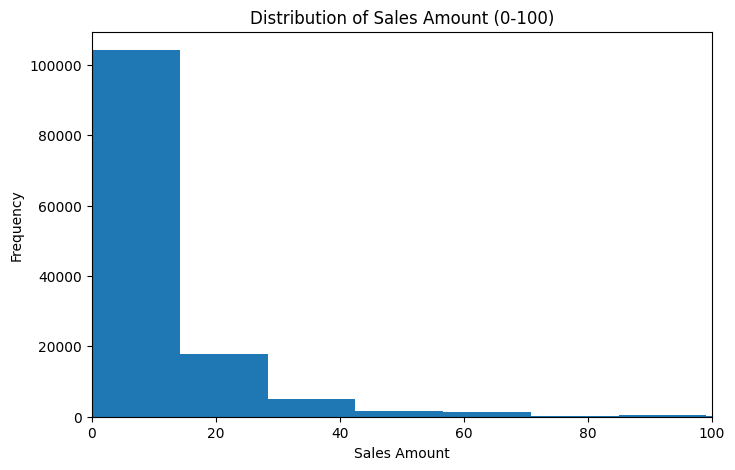

In [168]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales_Amount"], bins=50)

plt.xlim(0, 100)

plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Sales Amount (0-100)")

plt.show()

Sales_Amount is strongly right-skewed. Most transaction-line sales values are relatively small, while a small number of line items have substantially higher sales amounts.

In [169]:
print(df["Sales_Amount"].describe())
df.sort_values("Sales_Amount", ascending=False).head(10)

count    131706.000000
mean         11.981524
std          19.359699
min           0.020000
25%           4.230000
50%           6.920000
75%          12.330000
max         707.730000
Name: Sales_Amount, dtype: float64


,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,year,month,day,day_of_week,UnitPrice
104910,2016-11-09,20906,54485,6BZ,09K06,6.0,707.73,2016,11,9,Wednesday,117.955000
6059,2016-01-19,232,2874,6BZ,8CAJ4,5.0,531.27,2016,1,19,Tuesday,106.254000
69200,2016-08-12,4542,38844,PBV,BR7EP,2.0,505.59,2016,8,12,Friday,252.795000
102777,2016-07-17,20906,35034,6BZ,09K06,4.0,471.83,2016,7,17,Sunday,117.957500
42261,2016-04-29,10169,20852,6BZ,NACZN,3.0,424.63,2016,4,29,Friday,141.543333
25799,2016-03-16,4230,12497,6BZ,P35XJ,3.0,408.53,2016,3,16,Wednesday,136.176667
126780,2016-12-27,21065,63978,A38,RYHT4,2.0,398.13,2016,12,27,Tuesday,199.065000
98423,2016-10-22,18726,51560,SJS,OXKQ8,2.0,362.77,2016,10,22,Saturday,181.385000
33515,2016-04-06,17581,16429,HTR,S3KHW,3.0,357.75,2016,4,6,Wednesday,119.250000
54846,2016-06-01,20906,27258,6BZ,09K06,3.0,353.87,2016,6,1,Wednesday,117.956667


In [170]:
print("Rows:", len(df))
print("Unique transactions:", df["Transaction_ID"].nunique())
print("Unique customers:", df["Customer_ID"].nunique())
print("Unique products:", df["SKU"].nunique())
print("Unique categories:", df["SKU_Category"].nunique())

Rows: 131706
Unique transactions: 64682
Unique customers: 22625
Unique products: 5242
Unique categories: 187


In [171]:
transaction_sales = df.groupby("Transaction_ID")["Sales_Amount"].sum()
transaction_sales.describe()

count    64682.000000
mean        24.396874
std         38.613117
min          0.030000
25%          6.360000
50%         12.210000
75%         25.180000
max        707.730000
Name: Sales_Amount, dtype: float64

Since one transaction can contain multiple SKUs and therefore multiple rows, I grouped the data by Transaction_ID and summed Sales_Amount to calculate the total value of each customer transaction. This lets me analyze actual basket or bill values rather than individual transaction lines.

In [172]:
transaction_value = (
    df.groupby("Transaction_ID")["Sales_Amount"]
    .sum()
)

print("Average Transaction Value:", transaction_value.mean())

items_per_transaction = (
    df.groupby("Transaction_ID")["Quantity"]
    .sum()
)

print("Average items per transaction:", items_per_transaction.mean())

Average Transaction Value: 24.396874246312727
Average items per transaction: 3.0244029096193685


On average, a customer transaction contains about 3 items and generates roughly 24.4 units of sales value.

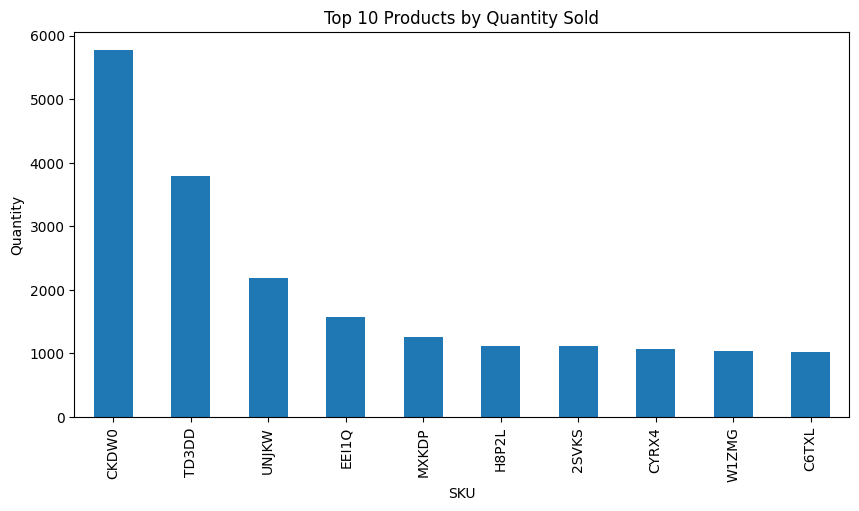

In [173]:
top_products = (
    df.groupby("SKU")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("SKU")
plt.ylabel("Quantity")
plt.show()

I grouped the dataset by SKU and summed Quantity to identify products with the highest total demand. This is more meaningful for inventory planning than simply counting how many rows contain each SKU because a single transaction can contain multiple units of the same product.

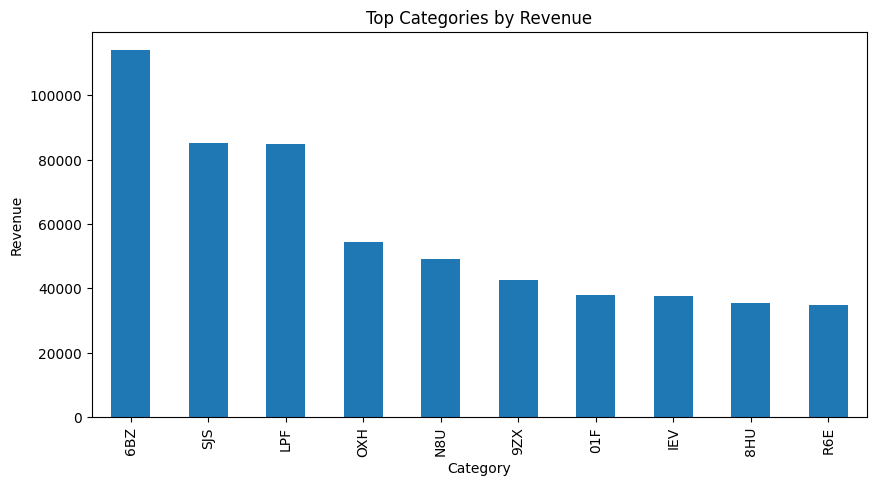

In [174]:
top_categories = (
    df.groupby("SKU_Category")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories.plot(kind="bar", figsize=(10,5))
plt.title("Top Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

I grouped transactions by SKU_Category and summed Sales_Amount to identify the categories contributing the most revenue. This can help a retailer understand which product groups are financially important, although revenue alone does not tell us profitability because the dataset does not contain product cost or margin information.

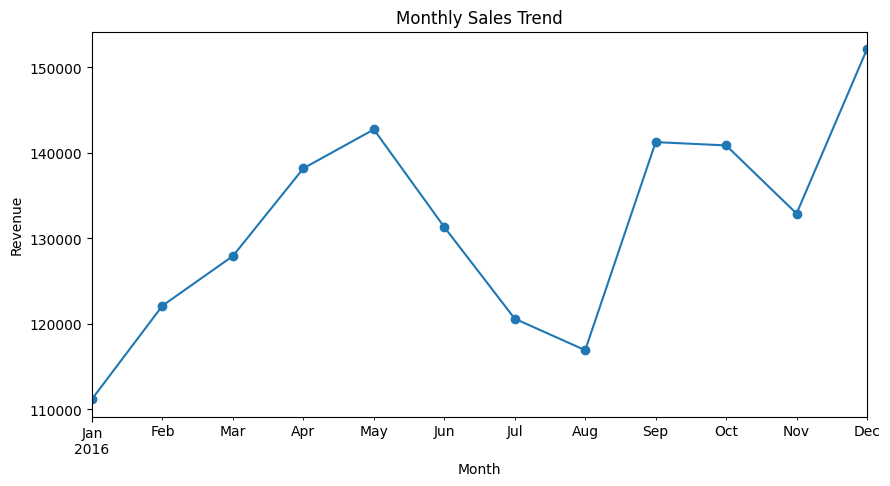

In [175]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Sales_Amount"]
    .sum()
)

monthly_sales.plot(figsize=(10,5), marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

I aggregated sales by month to understand how revenue changes over the observation period. Since the dataset covers roughly one year, this analysis can show monthly patterns, but I would need multiple years of data before confidently claiming recurring annual seasonality.

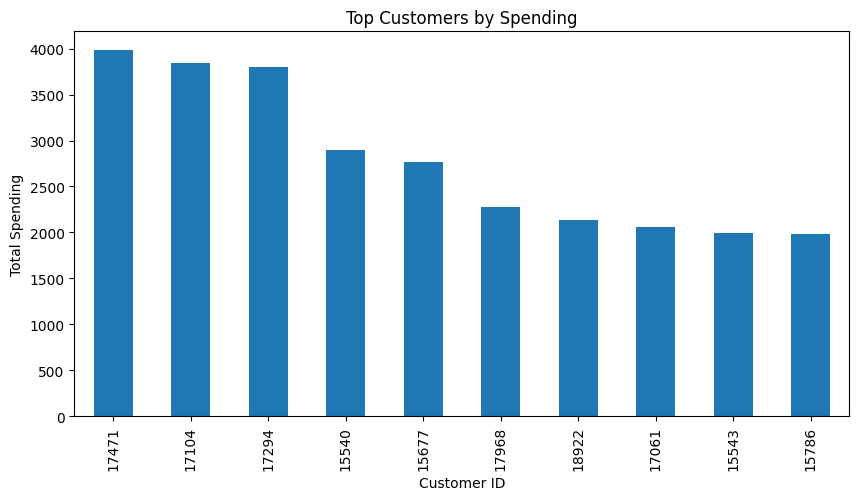

In [176]:
top_customers = (
    df.groupby("Customer_ID")["Sales_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind="bar", figsize=(10,5))
plt.title("Top Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

I aggregated Sales_Amount by customer to identify the customers who contributed the highest total revenue during the observation period. This analysis motivated the next step — RFM segmentation — because total spending alone does not capture whether a customer is recent or frequently engaged.

## 3. Exploratory Data Analysis

I focus the EDA on business questions rather than generating plots without a specific purpose.

The dataset does not contain a target label such as VIP, Loyal, or Inactive. Therefore, customer segmentation is not initially a supervised classification problem. I use unsupervised learning so that the algorithm discovers groups of customers with similar behavioural patterns. After inspecting the resulting cluster profiles, I assign human-readable business names to them.

Raw transaction rows are not directly suitable for customer segmentation, so I convert them into one row per customer.

Recency tells me how many days have passed since the customer's latest purchase. Lower Recency is generally better.

Frequency tells me how many distinct shopping transactions the customer has made. Higher Frequency generally indicates stronger engagement.

Monetary tells me how much the customer has spent in total. Higher Monetary value indicates greater financial importance to the business.

These three features convert transaction history into an interpretable customer-behaviour representation.

In [177]:
reference_date = df["Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer_ID").agg({
    "Date": lambda x: (reference_date - x.max()).days,
    "Transaction_ID": "nunique",
    "Sales_Amount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
1,345,1,16.29
2,196,2,22.77
3,365,1,10.92
4,53,2,33.29
5,180,5,78.82


# Recency = how recently customer purchased
# Frequency = how many transactions they made
# Monetary = total amount spent

In [178]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

K-Means calculates distances between customers. Since Monetary values can be much larger numerically than Frequency or Recency, using the raw variables could make Monetary dominate the distance calculation. StandardScaler transforms each feature to approximately zero mean and unit standard deviation so the three RFM dimensions contribute more comparably.

In [179]:
scores = []

for k in range(2, 7):
    temp_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = temp_model.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    scores.append(score)

    print("k =", k, "Silhouette Score =", score)

k = 2 Silhouette Score = 0.6862253450847852
k = 3 Silhouette Score = 0.5132896650568641
k = 4 Silhouette Score = 0.5274531191144008
k = 5 Silhouette Score = 0.5162565621964746
k = 6 Silhouette Score = 0.40812630853552173


K-Means requires me to specify the number of clusters beforehand, so I tested values of k from 2 to 6. For each value, I trained K-Means on the standardized RFM features and calculated the Silhouette Score, which measures how compact the customers are within their own cluster and how separated they are from other clusters. Higher scores generally indicate better-separated clusters. In my experiment, k=2 had the highest silhouette score, while I retained k=4 as an exploratory business segmentation because it gave more actionable customer profiles.

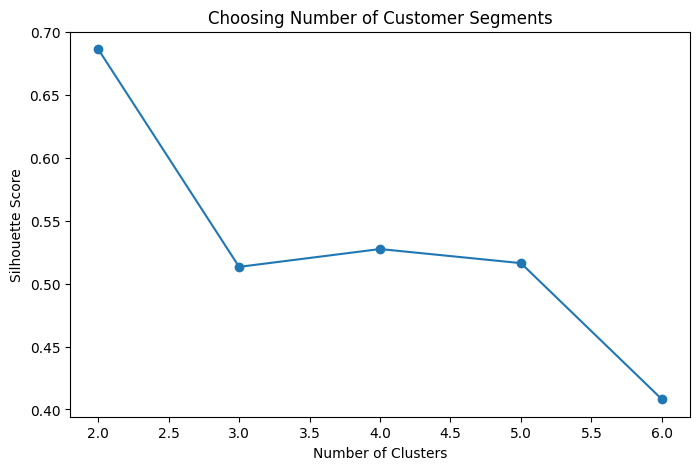

In [180]:
plt.figure(figsize=(8,5))

plt.plot(range(2,7), scores, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Choosing Number of Customer Segments")

plt.show()

## 4. Customer Segmentation using RFM and K-Means

### Why unsupervised learning?

K-Means requires the number of clusters to be specified beforehand. Instead of choosing k=4 only because four business segments are convenient, I can compare silhouette scores for different values of k. A higher silhouette score generally means customers are more clearly separated from other clusters. I still consider business interpretability along with the mathematical score when selecting the final number of segments.

In [181]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer_ID,,,,
1,345,1,16.29,0
2,196,2,22.77,0
3,365,1,10.92,0
4,53,2,33.29,1
5,180,5,78.82,0


In [182]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,273.848581,1.704066,35.314986
1,69.006244,2.249463,41.747876
2,21.930131,25.039301,1106.744585
3,57.867870,10.547730,307.574919


# The cluster summary shows:

## Cluster 0: Recency ≈ 274, Frequency ≈ 1.7, Monetary ≈ 35
### → customers who bought long ago, buy rarely, and spend little
### → good label: Inactive / Lost customers
## Cluster 1: Recency ≈ 69, Frequency ≈ 2.25, Monetary ≈ 42
### → somewhat recent but low-frequency and low-spending
### → good label: Occasional customers
## Cluster 3: Recency ≈ 58, Frequency ≈ 10.5, Monetary ≈ 308
### → buy fairly often and spend moderately
### → good label: Regular / Loyal customers
## Cluster 2: Recency ≈ 22, Frequency ≈ 25, Monetary ≈ 1107
### → very recent, very frequent, very high spending
### → good label: VIP / High-value customers

In [183]:
print(rfm["Cluster"].value_counts())

Cluster
0    10428
1    10250
3     1718
2      229
Name: count, dtype: int64


Cluster sizes show that VIP group is very small but highly valuable.

In [184]:
cluster_names = {
    0: "Inactive",
    1: "Occasional",
    2: "VIP",
    3: "Loyal"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

rfm[["Recency", "Frequency", "Monetary", "Customer_Segment"]].head()

,Recency,Frequency,Monetary,Customer_Segment
Customer_ID,,,,
1,345,1,16.29,Inactive
2,196,2,22.77,Inactive
3,365,1,10.92,Inactive
4,53,2,33.29,Occasional
5,180,5,78.82,Inactive


The clustering clearly separated the customer base into inactive, occasional, loyal and VIP customers. The VIP segment was small, but it had the highest purchase frequency and spending, while inactive customers had very high recency and low monetary value.

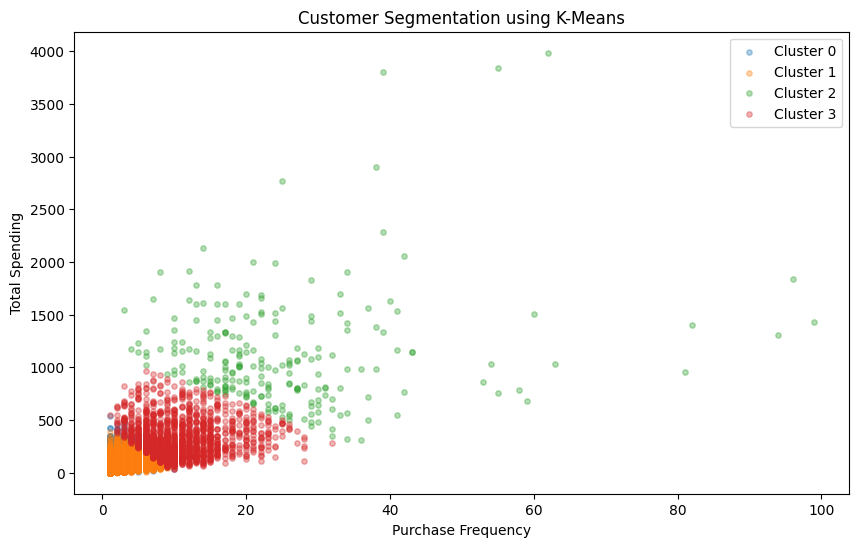

In [185]:
plt.figure(figsize=(10,6))

for cluster in sorted(rfm["Cluster"].unique()):
    temp = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        temp["Frequency"],
        temp["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.35,
        s=15
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

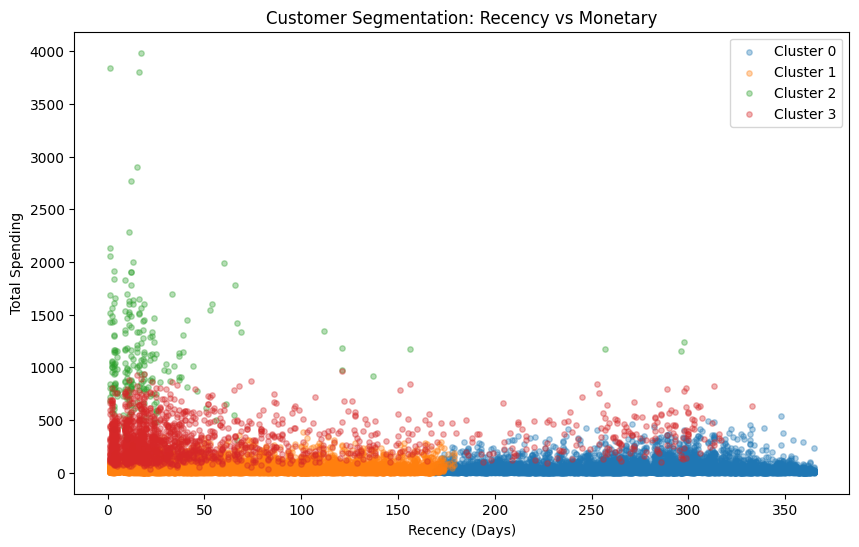

In [186]:
plt.figure(figsize=(10,6))

for cluster in sorted(rfm["Cluster"].unique()):
    temp = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        temp["Recency"],
        temp["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.35,
        s=15
    )

plt.xlabel("Recency (Days)")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation: Recency vs Monetary")
plt.legend()
plt.show()

Frequency vs Monetary
→ shows VIP/high-spending behaviour

Recency vs Monetary
→ clearly separates inactive customers

The clustering model uses three dimensions—Recency, Frequency and Monetary value. The 2D scatter plot only shows Frequency versus Monetary, so clusters that are primarily differentiated by Recency can visually overlap.

In [187]:
segment_summary = rfm.groupby("Customer_Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

print(segment_summary)

                     Recency  Frequency     Monetary
Customer_Segment                                    
Inactive          273.848581   1.704066    35.314986
Loyal              57.867870  10.547730   307.574919
Occasional         69.006244   2.249463    41.747876
VIP                21.930131  25.039301  1106.744585


I intentionally start with a simple Linear Regression model rather than immediately using a complex algorithm. A baseline gives me a reference point for judging whether more advanced approaches actually improve prediction quality.

Daily transaction rows are first aggregated into total sales per date. The model then attempts to explain daily sales using simple calendar information. This should be considered an initial benchmark rather than a production forecasting system.

## 5. Baseline Daily Sales Prediction

Customer segmentation is an unsupervised learning problem, but sales prediction is a supervised regression problem because historical daily sales provide a numerical target.

For the first baseline, I use Linear Regression with simple calendar features. The goal is not to build a production forecasting system yet, but to establish a simple benchmark.

In [188]:

daily_sales = (
    df.groupby("Date")["Sales_Amount"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Date,Sales_Amount
0,2016-01-02,1929.55
1,2016-01-03,798.15
2,2016-01-04,3273.27
3,2016-01-05,4919.03
4,2016-01-06,1559.72


In [189]:
daily_sales["day"] = daily_sales["Date"].dt.day
daily_sales["month"] = daily_sales["Date"].dt.month
daily_sales["day_of_week"] = daily_sales["Date"].dt.dayofweek

The raw dataset contains multiple transaction rows for each date, so I first group by Date and sum Sales_Amount to create one total sales value per day. Then I extract day, month, and day-of-week from the date as simple calendar features. These become the input features for my baseline Linear Regression model, while total daily Sales_Amount becomes the target variable.

In [190]:
X = daily_sales[["day", "month", "day_of_week"]]
y = daily_sales["Sales_Amount"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Date
 ↓
day
month
day_of_week
 ↓
Linear Regression
 ↓
Predicted Sales

In [191]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

I first implemented Linear Regression as a baseline model for sales prediction. The purpose was to establish baseline performance before moving to more suitable time-series or tree-based models.

In [192]:
y_pred = model.predict(X_test)

I split my data into 80% training and 20% testing data. I train Linear Regression on the training features and actual sales using fit(). Then I use predict() on the unseen test features to generate predicted daily sales. Finally, I compare those predictions with the actual y_test values using MAE, RMSE and R².

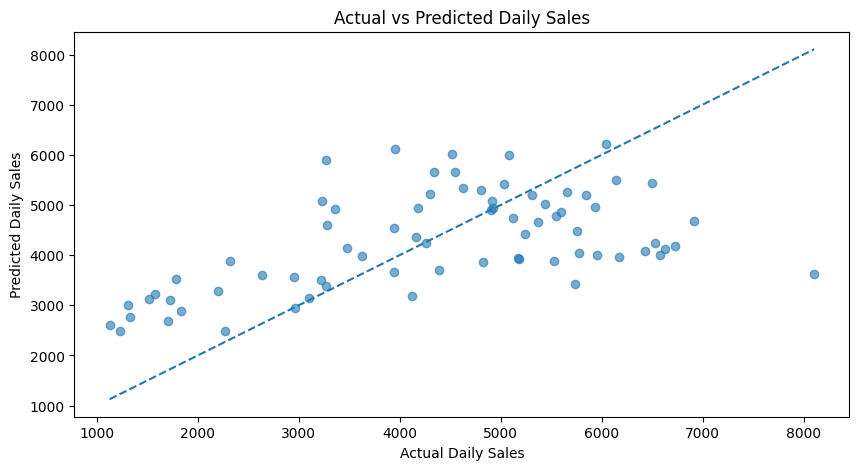

In [193]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Daily Sales")
plt.ylabel("Predicted Daily Sales")
plt.title("Actual vs Predicted Daily Sales")

plt.show()

To visually evaluate the baseline model, I compare the actual daily sales in the test set with the values predicted by Linear Regression.

The dashed diagonal line represents perfect predictions, where predicted sales are exactly equal to actual sales. Points closer to this line indicate better predictions, while points farther away represent larger prediction errors.

The noticeable spread around the line is consistent with the relatively modest R² score. This suggests that calendar features capture some sales patterns, but additional information would be required for stronger predictions.

In [194]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1124.8021244764586
RMSE: 1396.722912741493
R2 Score: 0.2831638553693382


I evaluate the baseline using three regression metrics:

MAE measures the average absolute difference between actual and predicted daily sales. It is easy to interpret because it uses the same units as the target.

RMSE also measures prediction error but gives larger errors more weight, so it is useful when large forecasting mistakes are particularly undesirable.

R² measures how much of the variation in daily sales is explained by the model relative to simply predicting the mean. An R² of 0.28 does not mean 28% accuracy; it means that approximately 28% of the variance was explained under that evaluation setup.

The relatively low R² suggests that simple calendar information alone is insufficient for strong retail forecasting.

This is a baseline Linear Regression model and currently uses only calendar features such as day, month and day of week. Sales depend on many additional factors, so the R² of 0.28 indicates that calendar features alone don't capture most of the sales variation. I would next introduce lag features and rolling averages and compare stronger models.

I would improve this by adding lag features, rolling averages, product-level demand, promotions, and by trying models such as Random Forest, XGBoost or dedicated time-series approaches.

## 6. Conclusion

DukaanBrain demonstrates how retail transaction data can be transformed into business-oriented insights.

The EDA helped identify important patterns in products, categories, customers and sales. The main machine-learning component uses RFM features with K-Means to identify different customer behaviour profiles.

I also implemented Linear Regression as a baseline daily-sales prediction experiment. Its moderate R² shows that basic calendar features capture only part of sales behaviour and that stronger forecasting would require richer historical and business features.

The long-term objective is to convert these analyses into simple recommendations that a small retailer could actually use.

# Data cleaning 
 ## EDA 
 ## Feature engineering 
 ## Customer segmentation
   ### K-Means 
 ## Sales prediction
   ### Linear Regression baseline 
 
 
 # Future work
  ## better forecasting
  ##  market basket analysis
  ## dashboard

DukaanBrain is a retail intelligence system targeted at small and medium businesses. I used transaction-level retail data and first performed cleaning and exploratory analysis to understand sales, customers, products and seasonal trends. I then created RFM features  Recency, Frequency and Monetary value  and used K-Means clustering to segment customers into behaviour based groups. I also implemented a baseline sales prediction model using historical date-related features. The eventual goal is to provide shopkeepers with actionable insights such as valuable customers, high demand products and future demand.

This notebook is an early prototype of DukaanBrain rather than a production retail forecasting system.

Current limitations include:

the customer clusters are based only on historical RFM behaviour;
K-Means assumes distance-based, roughly compact clusters and can be sensitive to skewed variables and outliers;
the number of clusters should be validated using quantitative measures such as silhouette score together with business interpretability;
the sales model currently uses a small set of calendar features;
the dataset does not contain promotions, holidays, inventory availability, product cost, profit margins or other external demand drivers;
one year of data is not sufficient to make strong conclusions about long-term seasonality.

Future improvements would include lagged sales, rolling averages, stronger time-series evaluation, tree-based models, market-basket analysis, product-level demand forecasting and a Streamlit dashboard for business users.